Connected to base (Python 3.9.13)

In [1]:
import palantir
import scanpy as sc
import pandas as pd
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

process data

In [3]:
ad = sc.read('/home/yzhao4/branch_point_prediction/Data/marrow_sample_scseq_counts.h5ad')
ad.layers['counts'] = ad.X.copy()

sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)
sc.pp.highly_variable_genes(ad,flavor="cell_ranger") # n_top_genes=1500, 
sc.pp.pca(ad)
ad

dm_res = palantir.utils.run_diffusion_maps(ad, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(ad)
sc.pp.neighbors(ad)
sc.tl.umap(ad)


/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [ ]:
sc.tl.leiden(ad, resolution=0.99)
sc.pl.umap(ad, color=['leiden'], frameon=False, size=10, alpha=0.5)

leiden clustering with high resolution

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


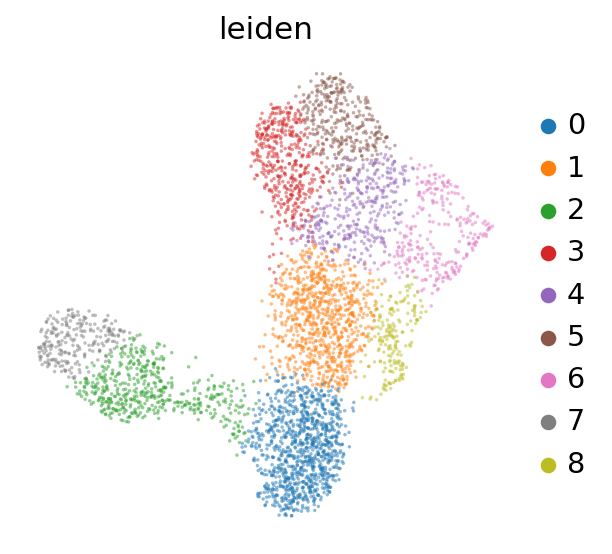

In [5]:
ad = sc.read_h5ad('/home/yzhao4/new_repo_branchpoint/Data/Palantir_bone_marrow/data/data_palantir_pseudotime_leiden_clustering.h5ad')

sc.settings.set_figure_params(
    dpi_save=300,       # ensures saving also uses 300 dpi
)

sc.pl.umap(ad, color=['leiden'], frameon=False, size=10, alpha=0.5, 
           save="palantir_data_leiden_clustering.png")



map the 3 cells with annotations to clusters

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


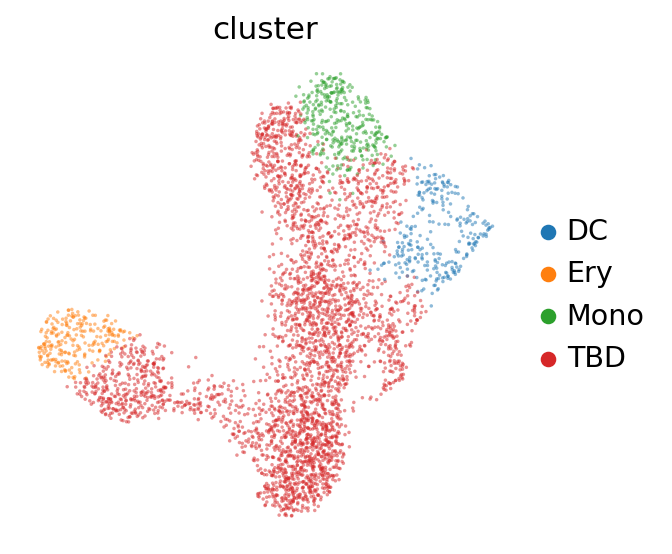

In [6]:

terminal_states = pd.Series(
    ["DC", "Mono", "Ery"],
    index=["Run5_131097901611291", "Run5_134936662236454", "Run4_200562869397916"],
)

annotations = ad.obs[['leiden']].copy(deep=True).astype(str)
annotated_cluster = annotations.loc[terminal_states.index]
annotations[~annotations['leiden'].isin(annotated_cluster['leiden'].tolist())] = 'TBD'
annotations = annotations.replace({
    annotated_cluster.loc["Run5_131097901611291", 'leiden']: 'DC',
    annotated_cluster.loc["Run5_134936662236454", 'leiden']: 'Mono',
    annotated_cluster.loc["Run4_200562869397916", 'leiden']: 'Ery'
})
ad.obs['cluster'] = annotations.loc[ad.obs_names]['leiden'].tolist()
sc.pl.umap(ad, color=['cluster'], frameon=False, size=10, alpha=0.5,
           save="palantir_data_terminal_state_annotation.png")

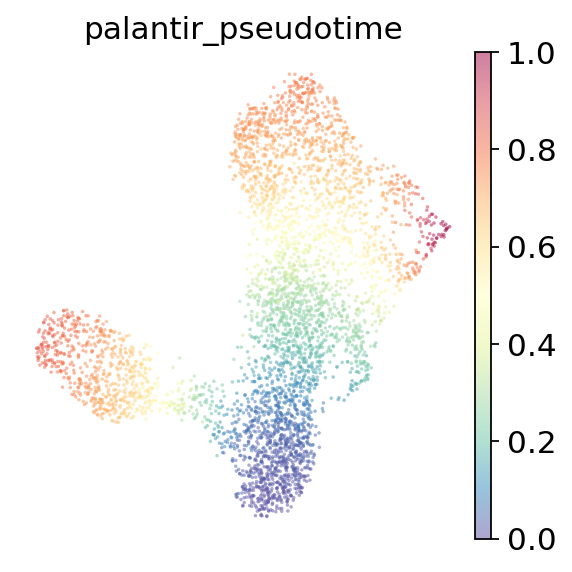

In [7]:
sc.pl.umap(ad, color=['palantir_pseudotime'], frameon=False, size=10, alpha=0.5,
           save="palantir_data_pseudotime.png")

run palantir

Sampling and flocking waypoints...
Time for determining waypoints: 0.005023670196533203 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.0781379461288452 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


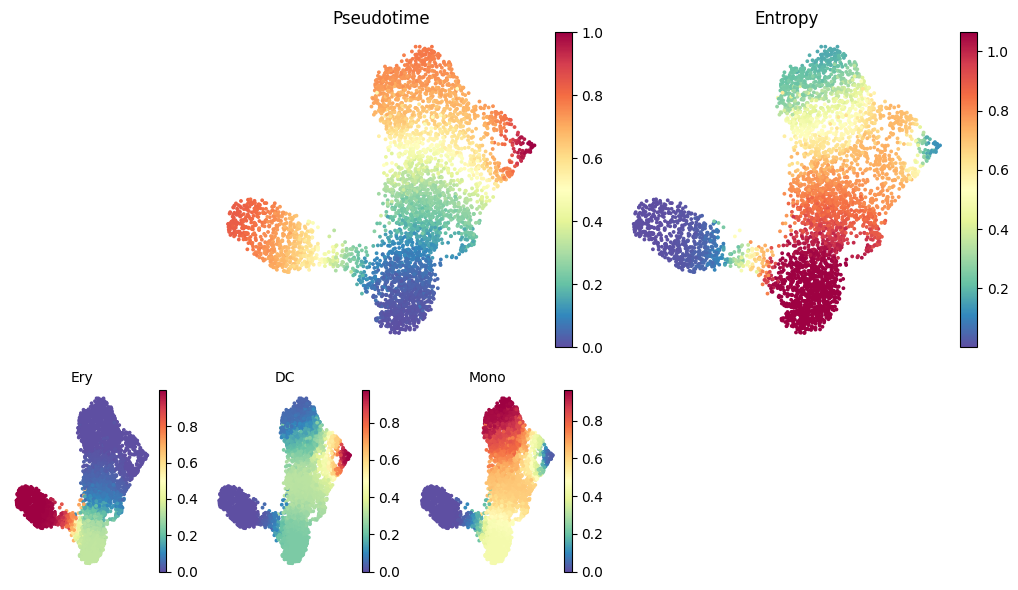

In [6]:
start_cell = "Run5_164698952452459"
pr_res = palantir.core.run_palantir(
    ad, start_cell, num_waypoints=500, terminal_states=terminal_states
)

palantir.plot.plot_palantir_results(ad, s=3)
plt.show()


In [19]:
ad
ad.write_h5ad('/home/yzhao4/new_repo_branchpoint/Data/Palantir_bone_marrow/data/data_palantir_pseudotime_leiden_clustering.h5ad')